# Direct Call LLM 检测结果可视化

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 加载数据
with open('direct_call_llm_local_qwen2_5.json', 'r') as f:
    qwen2_5_data = json.load(f)

with open('direct_call_llm_local_deepseek.json', 'r') as f:
    deepseek_data = json.load(f)

months = qwen2_5_data['month']
qwen2_5_precision = qwen2_5_data['precision']
qwen2_5_recall = qwen2_5_data['recall']
qwen2_5_f1 = qwen2_5_data['f1']

deepseek_precision = deepseek_data['precision']
deepseek_recall = deepseek_data['recall']
deepseek_f1 = deepseek_data['f1']

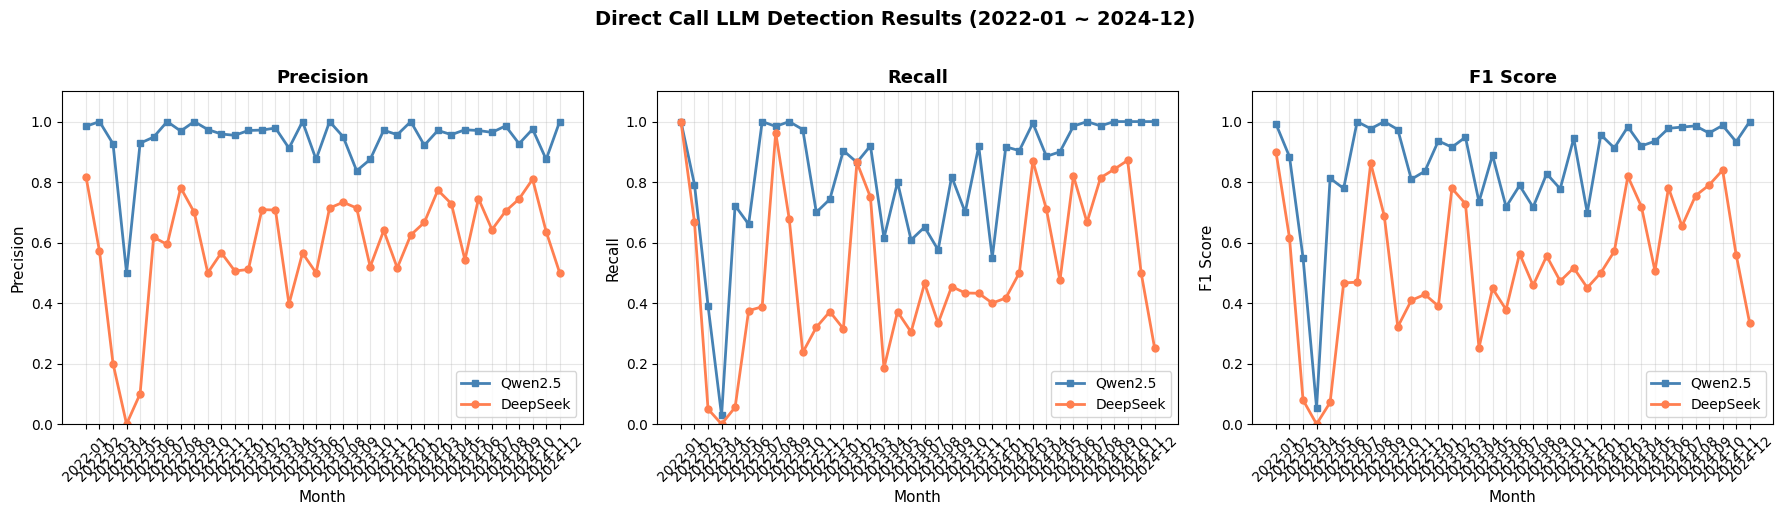

In [2]:
# 绘制3个子图：Precision, Recall, F1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1: Precision
axes[0].plot(months, qwen2_5_precision, 's-', label='Qwen2.5', color='steelblue', linewidth=2, markersize=5)
axes[0].plot(months, deepseek_precision, 'o-', label='DeepSeek', color='coral', linewidth=2, markersize=5)
axes[0].set_xlabel('Month', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 子图2: Recall
axes[1].plot(months, qwen2_5_recall, 's-', label='Qwen2.5', color='steelblue', linewidth=2, markersize=5)
axes[1].plot(months, deepseek_recall, 'o-', label='DeepSeek', color='coral', linewidth=2, markersize=5)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# 子图3: F1
axes[2].plot(months, qwen2_5_f1, 's-', label='Qwen2.5', color='steelblue', linewidth=2, markersize=5)
axes[2].plot(months, deepseek_f1, 'o-', label='DeepSeek', color='coral', linewidth=2, markersize=5)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].set_ylabel('F1 Score', fontsize=11)
axes[2].set_title('F1 Score', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].set_ylim(0, 1.1)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Direct Call LLM Detection Results (2022-01 ~ 2024-12)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 统计信息
print("="*50)
print("Direct Call LLM 统计对比")
print("="*50)
print(f"Qwen2.5   - Mean Precision: {np.mean(qwen2_5_precision):.4f}, Mean Recall: {np.mean(qwen2_5_recall):.4f}, Mean F1: {np.mean(qwen2_5_f1):.4f}")
print(f"DeepSeek  - Mean Precision: {np.mean(deepseek_precision):.4f}, Mean Recall: {np.mean(deepseek_recall):.4f}, Mean F1: {np.mean(deepseek_f1):.4f}")

qwen2_5_f1_arr = np.array(qwen2_5_f1)
deepseek_f1_arr = np.array(deepseek_f1)

improved = np.sum(qwen2_5_f1_arr > deepseek_f1_arr)
degraded = np.sum(qwen2_5_f1_arr < deepseek_f1_arr)
same = np.sum(qwen2_5_f1_arr == deepseek_f1_arr)
print(f"Qwen2.5相比DeepSeek提升的月份数: {improved}, 下降: {degraded}, 相同: {same}")